# ECON 3916: ML Prediction Project — Final Project

Ian Solberg

April 15, 2026

Professor Piao

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [2]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** ___

**This is a prediction (umbrella) problem because:** ___
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** ___
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** FRED api data dump - Jan 2000 -> present, weekly with lags and scoring columns applied 
- **Source:** FREDapi via FRED_Loader custom module developed for easy data dumps in research by myself.
- **N =** 1918 weeks
- **Features =** 216 series
- **Target variable =** Median Household Income
- **Access date:** April 15, 2026 (Most recent Friday is final row)

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [3]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv("data/fred_subset.csv")  # Example: local file
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (998, 34)
Columns: ['date', 'Unemployment_Rate', 'U6_Underemployment', 'Nonfarm_Payrolls', 'JOLTS_Quits', 'Employment_Population_Ratio', 'Part_Time_Economic_Reasons', 'Labor_Force_Participation', 'Initial_Jobless_Claims', 'JOLTS_UE_Ratio', 'Sahm_Indicator', 'Payroll_Change_4w', 'Industrial_Production', 'Capacity_Utilization', 'Retail_Sales', 'Leading_Index_CB', 'Activity_Momentum', 'CPI_YoY', 'Core_PCE_YoY', 'Inflation_Momentum', 'Real_FFR_PCE', 'Taylor_Gap', 'Treasury_10Y', 'HY_OAS_Spread', 'Chicago_Fed_Financial_Conditions', 'Flag_Curve_Inverted_10Y2Y', 'Personal_Savings_Rate', 'Credit_Impulse', 'Mortgage_Rate_30Y', 'Housing_Pressure', 'Working_Age_Population', 'Sentiment_Lag_13w', 'Flag_Sahm_Triggered', 'Avg_Weekly_Earnings_YoY']


,date,Unemployment_Rate,U6_Underemployment,Nonfarm_Payrolls,JOLTS_Quits,Employment_Population_Ratio,Part_Time_Economic_Reasons,Labor_Force_Participation,Initial_Jobless_Claims,JOLTS_UE_Ratio,...,Chicago_Fed_Financial_Conditions,Flag_Curve_Inverted_10Y2Y,Personal_Savings_Rate,Credit_Impulse,Mortgage_Rate_30Y,Housing_Pressure,Working_Age_Population,Sentiment_Lag_13w,Flag_Sahm_Triggered,Avg_Weekly_Earnings_YoY
0,2007-03-02,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,322000.0,0.70483,...,-0.647,1,3.0,-0.415748,6.18,-9.969020,195159800.0,91.7,0,3.997841
1,2007-03-09,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,320000.0,0.70483,...,-0.633,1,3.0,-0.415748,6.14,-9.978720,195159800.0,91.7,0,3.997841
2,2007-03-16,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,308000.0,0.70483,...,-0.620,1,3.0,-0.415748,6.14,-9.948190,195159800.0,91.7,0,3.997841
3,2007-03-23,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,309000.0,0.70483,...,-0.612,1,3.0,-0.415748,6.16,-9.897582,195159800.0,91.7,0,3.997841
4,2007-03-30,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,303000.0,0.70483,...,-0.606,0,3.0,-0.415748,6.16,-9.865982,195159800.0,91.7,0,3.997841


### 2.2 Basic Description

In [4]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              998 non-null    str    
 1   Unemployment_Rate                 998 non-null    float64
 2   U6_Underemployment                998 non-null    float64
 3   Nonfarm_Payrolls                  998 non-null    float64
 4   JOLTS_Quits                       998 non-null    float64
 5   Employment_Population_Ratio       998 non-null    float64
 6   Part_Time_Economic_Reasons        998 non-null    float64
 7   Labor_Force_Participation         998 non-null    float64
 8   Initial_Jobless_Claims            998 non-null    float64
 9   JOLTS_UE_Ratio                    998 non-null    float64
 10  Sahm_Indicator                    998 non-null    float64
 11  Payroll_Change_4w                 998 non-null    float64
 12  Industrial_Producti

In [5]:
df.describe()

,Unemployment_Rate,U6_Underemployment,Nonfarm_Payrolls,JOLTS_Quits,Employment_Population_Ratio,Part_Time_Economic_Reasons,Labor_Force_Participation,Initial_Jobless_Claims,JOLTS_UE_Ratio,Sahm_Indicator,...,Chicago_Fed_Financial_Conditions,Flag_Curve_Inverted_10Y2Y,Personal_Savings_Rate,Credit_Impulse,Mortgage_Rate_30Y,Housing_Pressure,Working_Age_Population,Sentiment_Lag_13w,Flag_Sahm_Triggered,Avg_Weekly_Earnings_YoY
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,9.980000e+02,998.000000,998.000000,...,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,9.980000e+02,998.000000,998.000000,998.000000
mean,5.827655,10.724749,143628.775551,2898.166333,59.605110,27.948096,63.307816,3.733667e+05,0.796609,0.628241,...,-0.292450,0.122244,6.278858,-0.039152,4.737806,-0.661495,2.040213e+08,78.130561,0.174349,3.126389
std,2.195709,3.569805,9063.747329,706.712243,1.524143,9.314751,1.285339,4.029822e+05,0.499788,1.330482,...,0.584428,0.327732,3.403984,5.449192,1.259407,7.221141,4.352094e+06,13.652221,0.379599,1.196944
min,3.400000,6.600000,129706.000000,1555.000000,51.200000,4.000000,60.100000,1.900000e+05,0.146842,0.000000,...,-0.793000,0.000000,1.900000,-17.913638,2.650000,-17.933793,1.951598e+08,50.000000,0.000000,0.721474
25%,4.100000,7.800000,136279.000000,2296.000000,58.600000,20.700000,62.600000,2.260000e+05,0.332620,0.076923,...,-0.569000,0.000000,5.025000,-1.358801,3.780000,-3.552743,2.004218e+08,67.900000,0.000000,2.296869
50%,5.000000,9.600000,142863.000000,2989.000000,59.700000,24.800000,62.900000,2.895000e+05,0.713138,0.169231,...,-0.469000,0.000000,5.700000,-0.159081,4.400000,-0.265793,2.053065e+08,76.850000,0.000000,2.914917
75%,7.500000,13.900000,150926.500000,3386.000000,60.300000,36.700000,64.000000,3.870000e+05,1.130488,0.400000,...,-0.274250,0.000000,6.600000,1.117198,6.060000,2.218961,2.066388e+08,90.925000,0.000000,3.671020
max,14.800000,22.900000,158637.000000,4499.000000,63.300000,45.500000,66.200000,6.137000e+06,2.077872,9.515385,...,3.062000,1.000000,31.800000,19.230344,7.790000,13.485991,2.123523e+08,101.400000,1.000000,7.529169


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


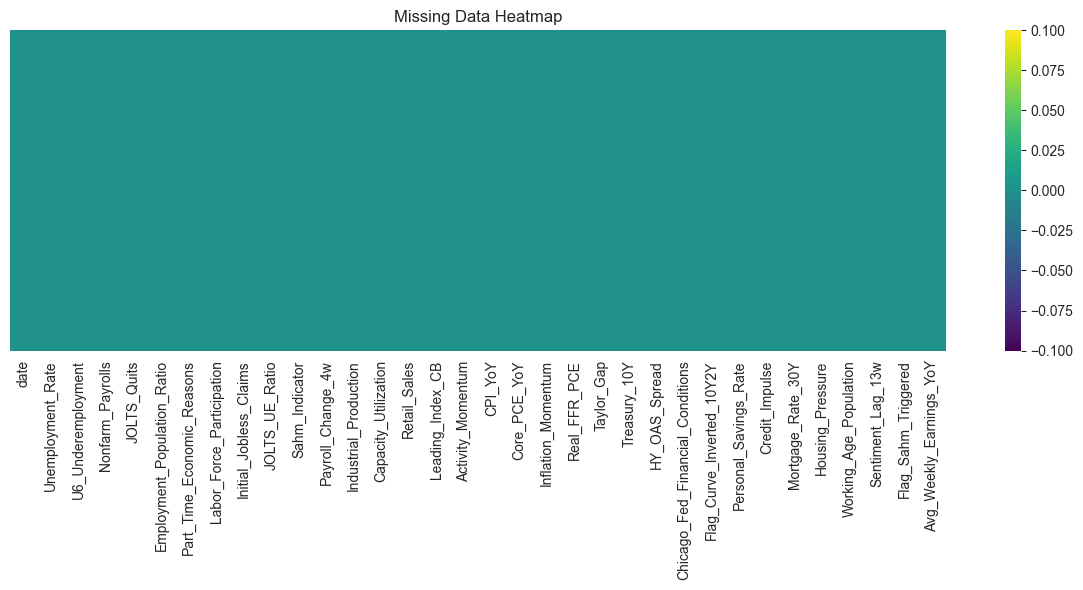

In [6]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** None - there is no missing data. 

completely clean.

In [7]:
print('Data is now completely clean.')
# size and shape of the cleaned dataset
print(f'Cleaned Shape: {df.shape}')

Data is now completely clean.
Cleaned Shape: (998, 34)


### 2.4 Distribution Plots

In [8]:
df

,date,Unemployment_Rate,U6_Underemployment,Nonfarm_Payrolls,JOLTS_Quits,Employment_Population_Ratio,Part_Time_Economic_Reasons,Labor_Force_Participation,Initial_Jobless_Claims,JOLTS_UE_Ratio,...,Chicago_Fed_Financial_Conditions,Flag_Curve_Inverted_10Y2Y,Personal_Savings_Rate,Credit_Impulse,Mortgage_Rate_30Y,Housing_Pressure,Working_Age_Population,Sentiment_Lag_13w,Flag_Sahm_Triggered,Avg_Weekly_Earnings_YoY
0,2007-03-02,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,322000.0,0.704830,...,-0.647,1,3.0,-0.415748,6.18,-9.969020,195159800.0,91.7,0,3.997841
1,2007-03-09,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,320000.0,0.704830,...,-0.633,1,3.0,-0.415748,6.14,-9.978720,195159800.0,91.7,0,3.997841
2,2007-03-16,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,308000.0,0.704830,...,-0.620,1,3.0,-0.415748,6.14,-9.948190,195159800.0,91.7,0,3.997841
3,2007-03-23,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,309000.0,0.704830,...,-0.612,1,3.0,-0.415748,6.16,-9.897582,195159800.0,91.7,0,3.997841
4,2007-03-30,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,303000.0,0.704830,...,-0.606,0,3.0,-0.415748,6.16,-9.865982,195159800.0,91.7,0,3.997841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,2026-03-13,4.3,8.0,158637.0,2974.0,59.2,25.4,61.9,213000.0,1.000291,...,-0.472,0,4.0,-0.782093,6.11,-6.609707,212352300.0,52.9,0,3.517523
994,2026-03-20,4.3,8.0,158637.0,2974.0,59.2,25.4,61.9,205000.0,1.000291,...,-0.462,0,4.0,-0.782093,6.22,-6.463526,212352300.0,52.9,0,3.517523
995,2026-03-27,4.3,8.0,158637.0,2974.0,59.2,25.4,61.9,211000.0,1.000291,...,-0.456,0,4.0,-0.782093,6.38,-6.262376,212352300.0,52.9,0,3.517523
996,2026-04-03,4.3,8.0,158637.0,2974.0,59.2,25.4,61.9,203000.0,1.000291,...,-0.458,0,4.0,-1.365146,6.46,-5.887362,212352300.0,56.4,0,3.186646


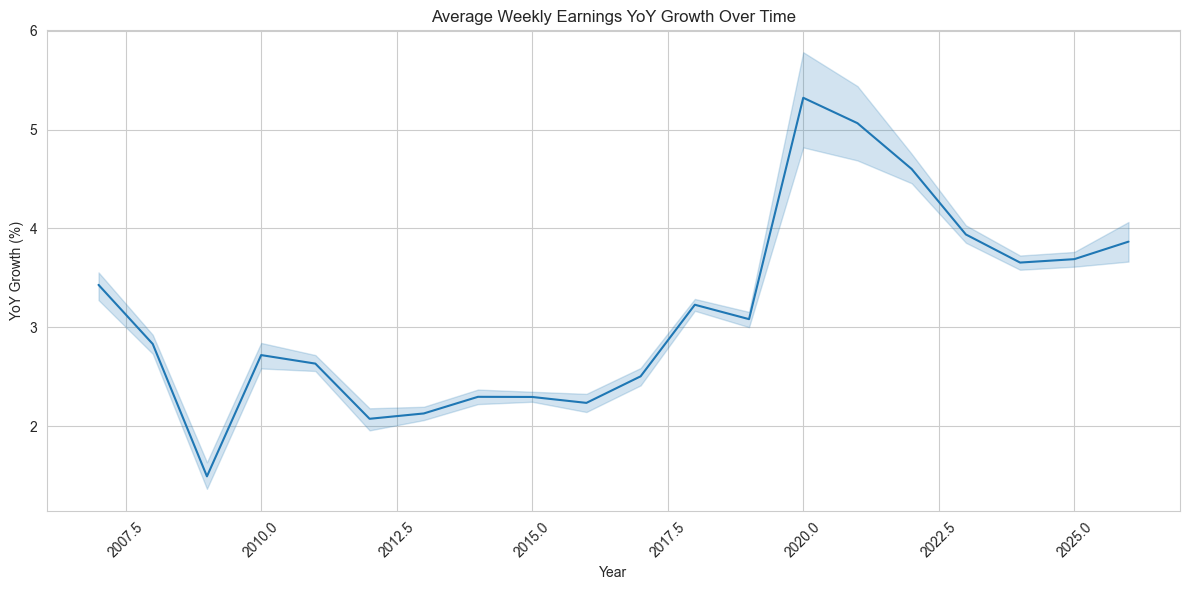

In [9]:
# graph time series of target variable - 
# x axis only shows year and not month for better readability, and also rotates x-axis labels for better readability
# get years to graph
df['year'] = pd.to_datetime(df['date']).dt.year
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='Avg_Weekly_Earnings_YoY', data=df)
plt.title('Average Weekly Earnings YoY Growth Over Time')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

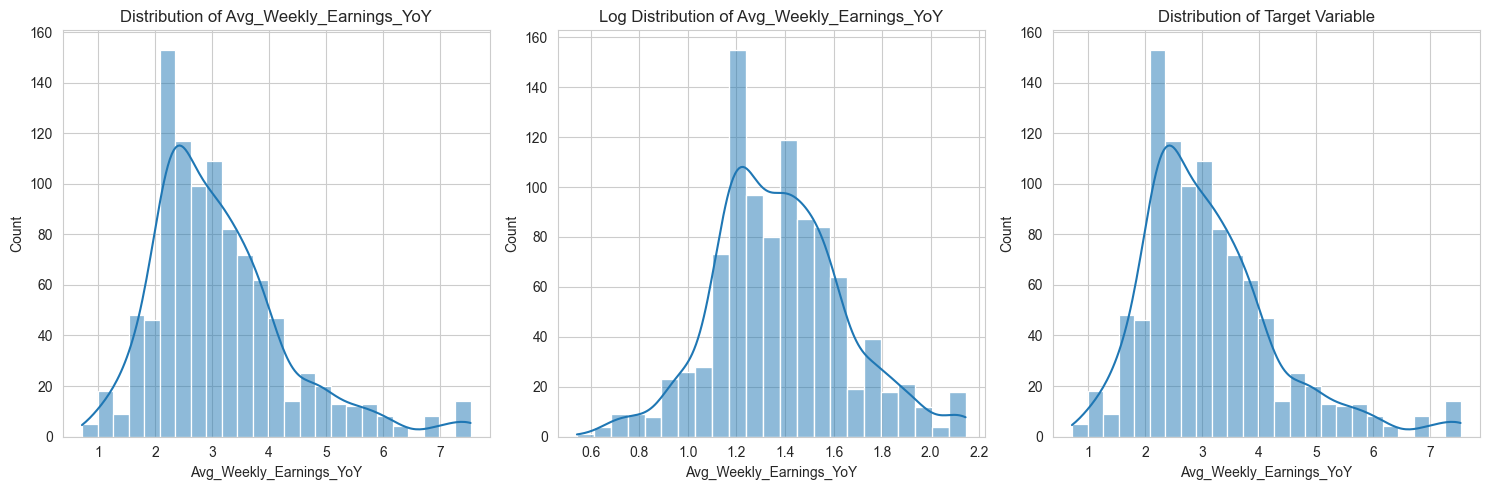

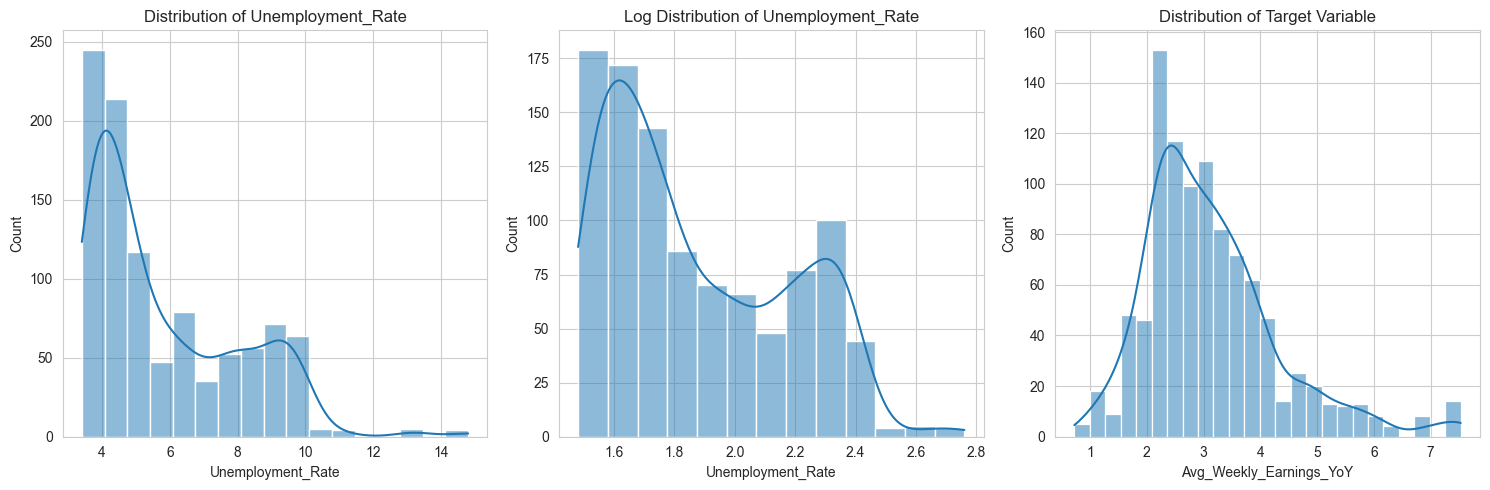

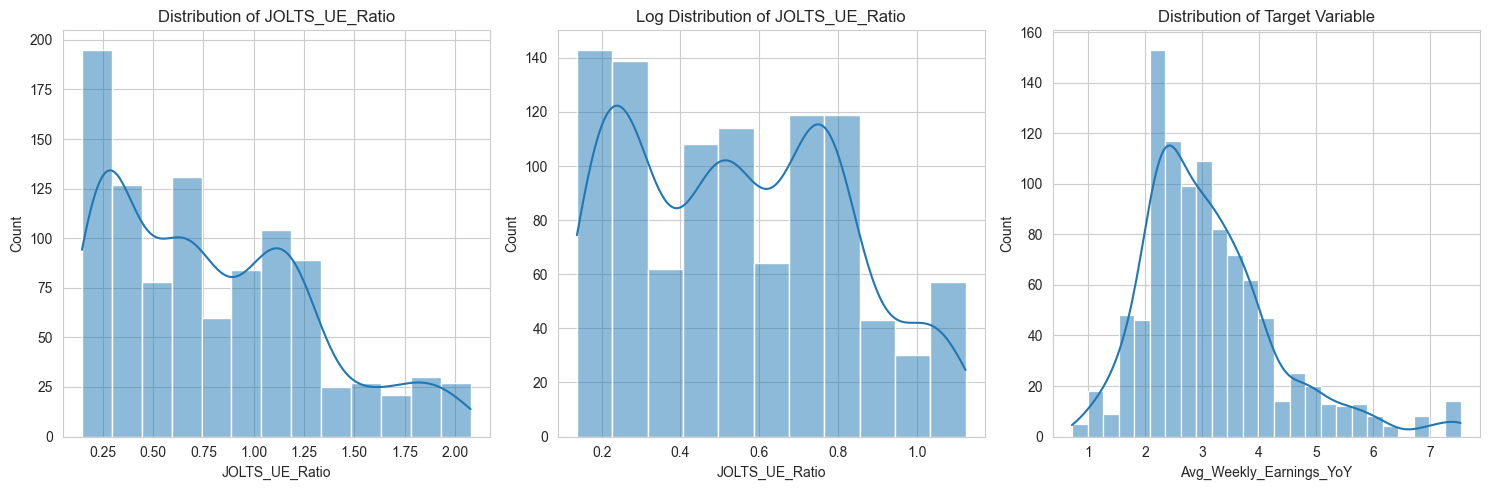

/Users/ian/Desktop/MAINFRAME/School/Year 3/Year3Sem2/MachineLearning/ML_Prediction_Project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


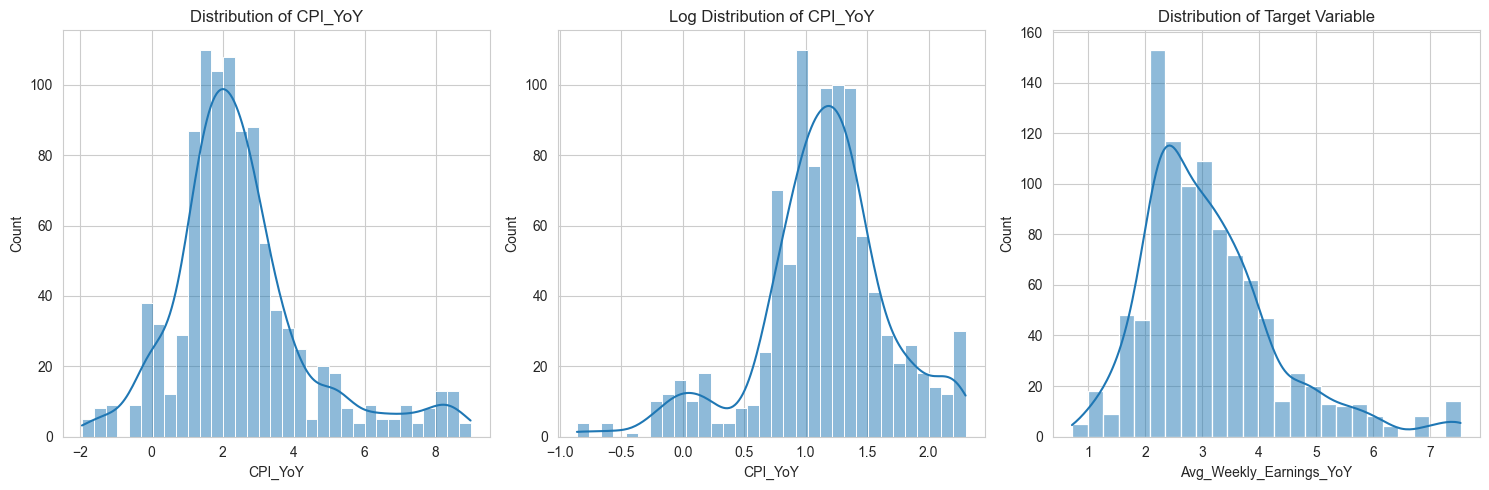

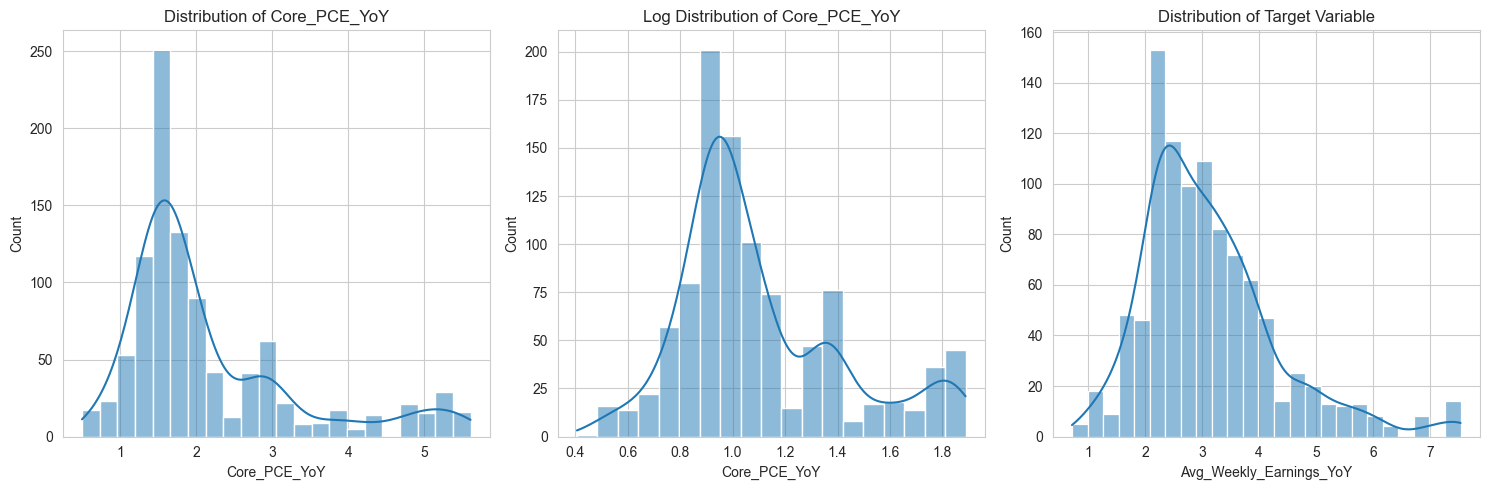

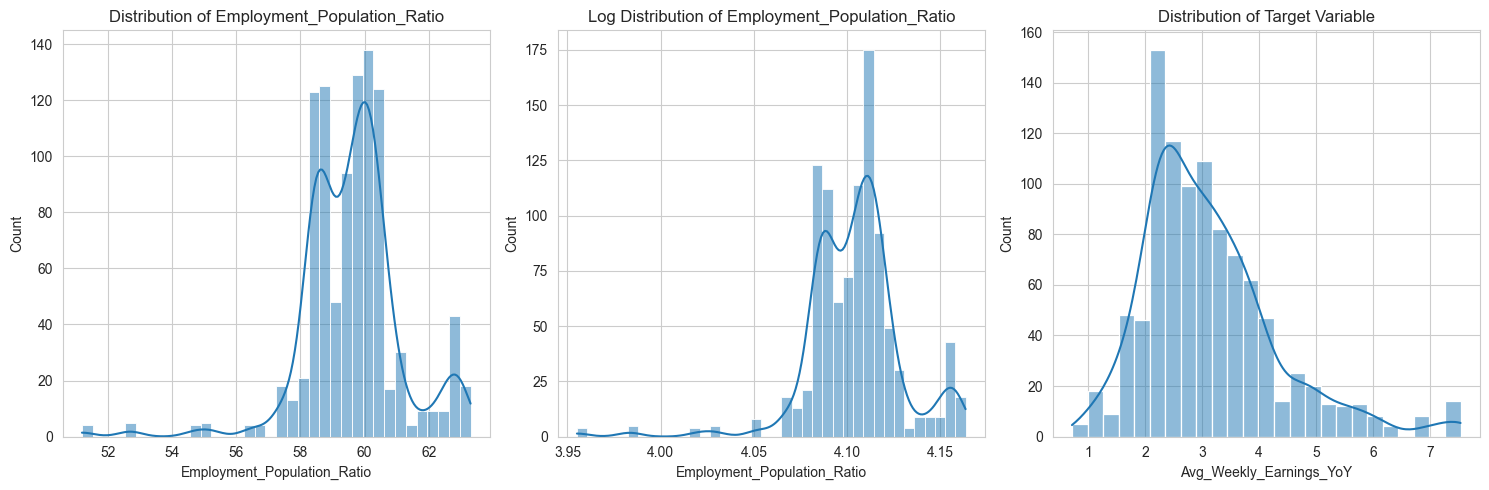

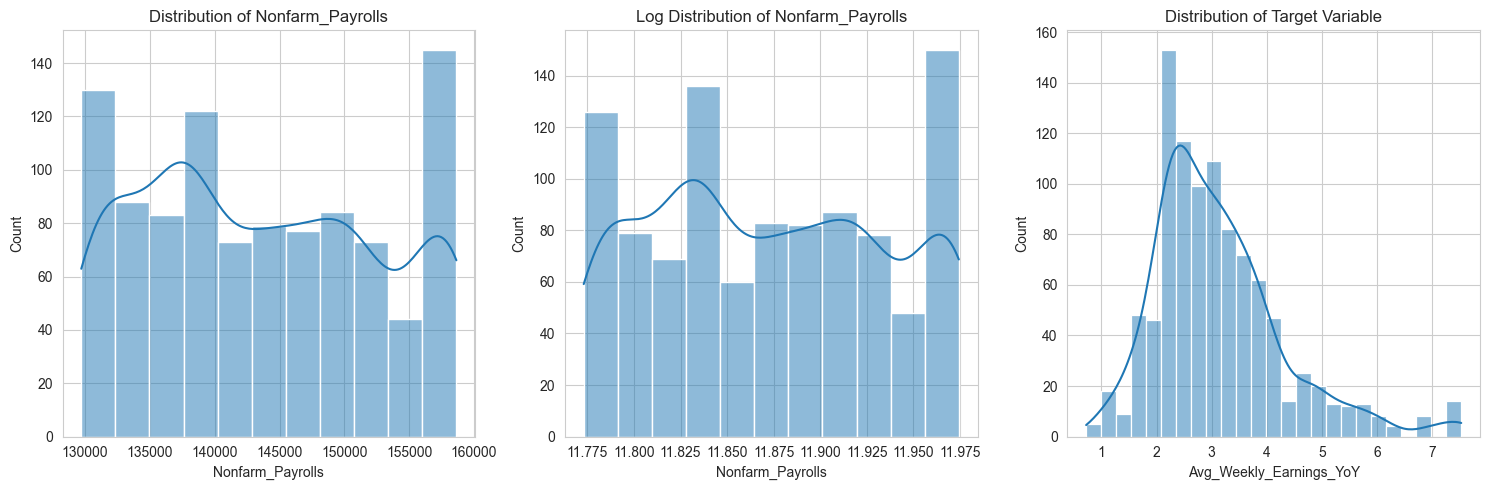

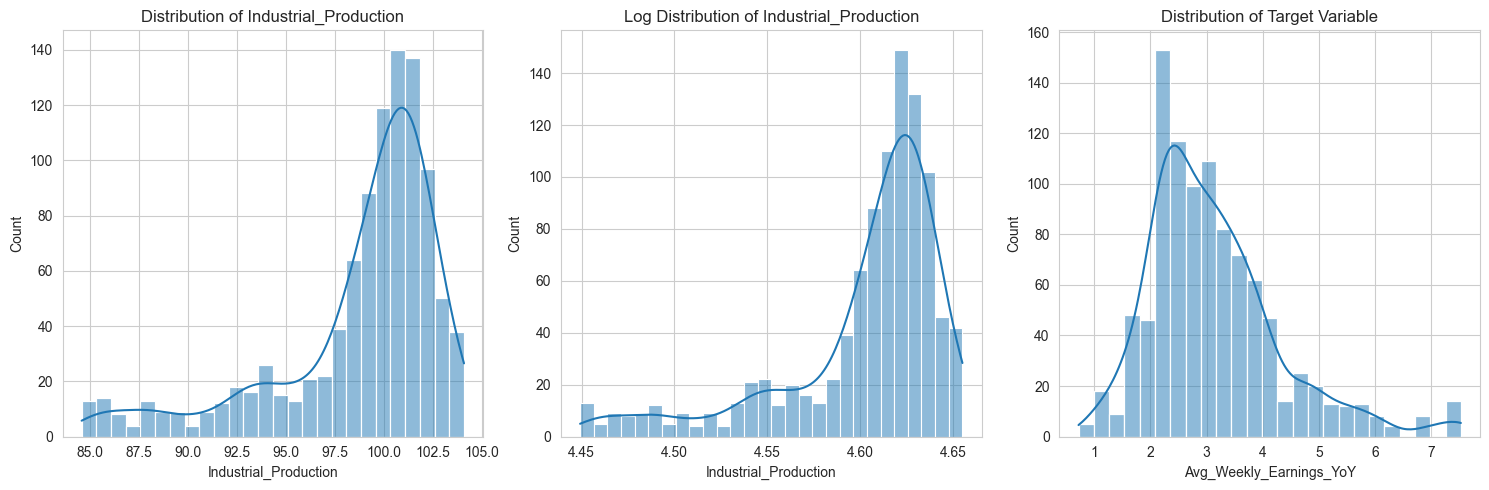

/Users/ian/Desktop/MAINFRAME/School/Year 3/Year3Sem2/MachineLearning/ML_Prediction_Project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


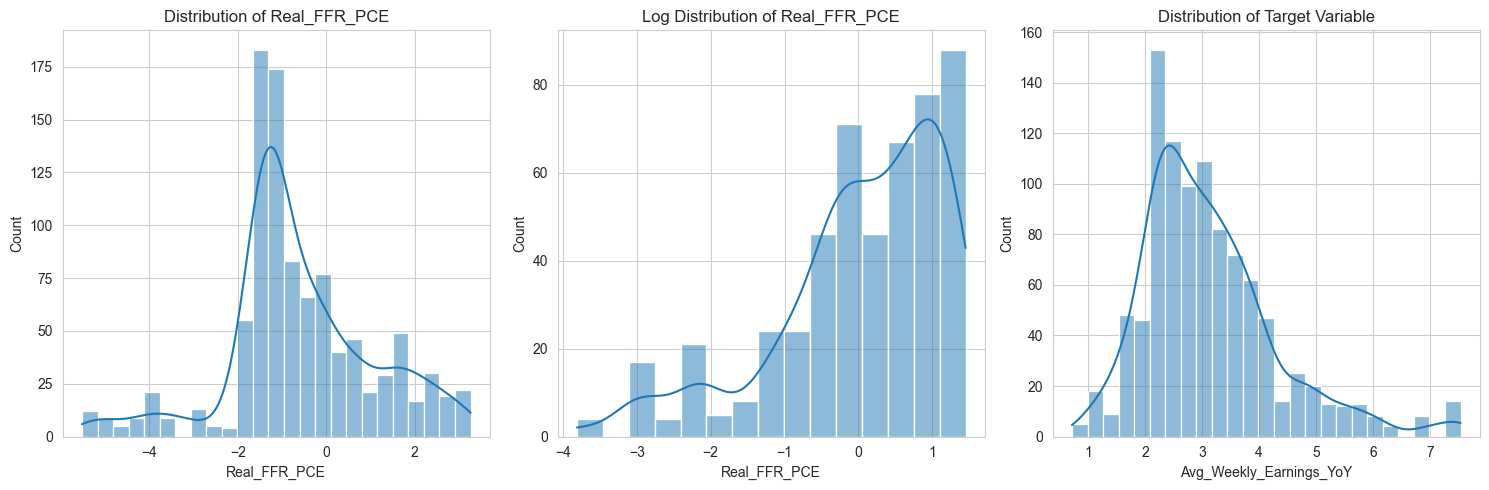

/Users/ian/Desktop/MAINFRAME/School/Year 3/Year3Sem2/MachineLearning/ML_Prediction_Project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


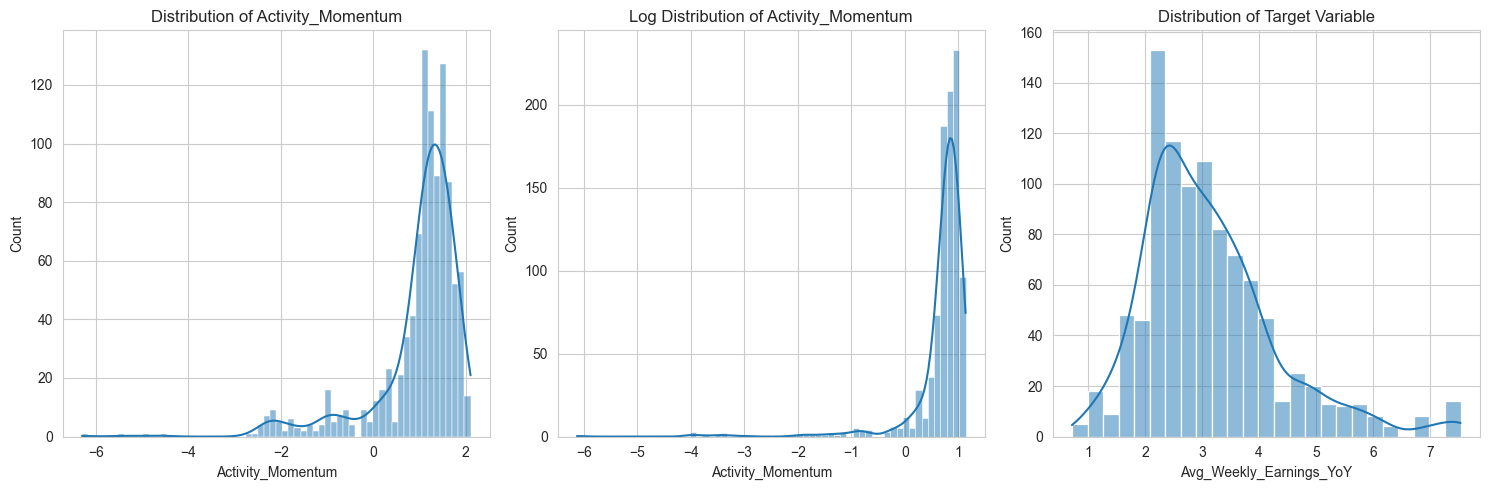

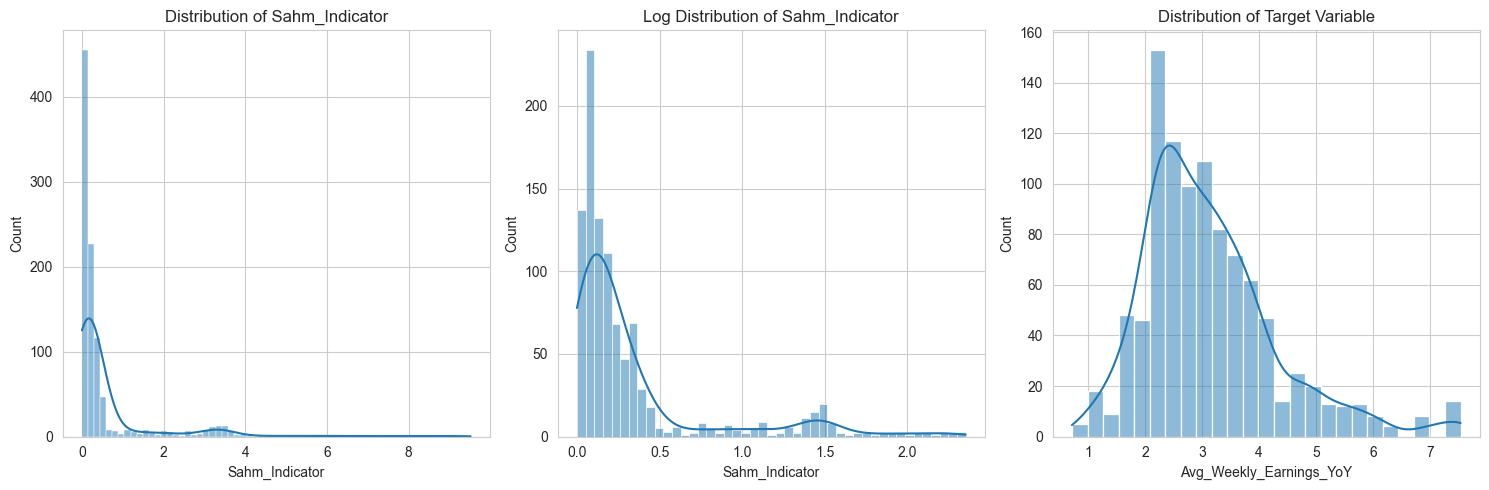

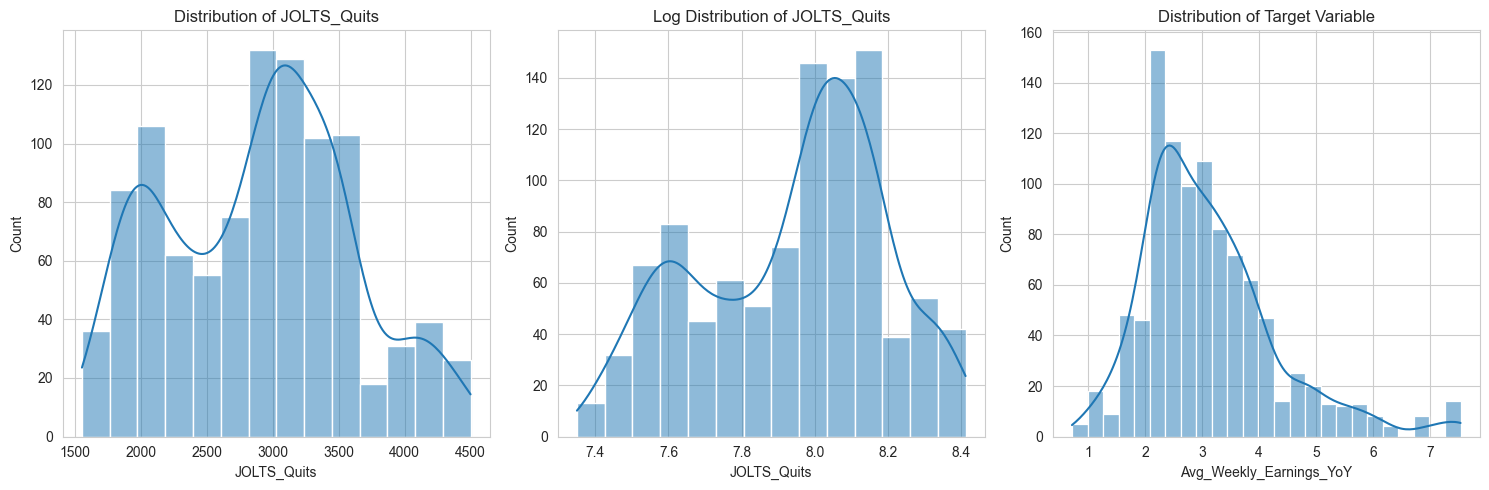

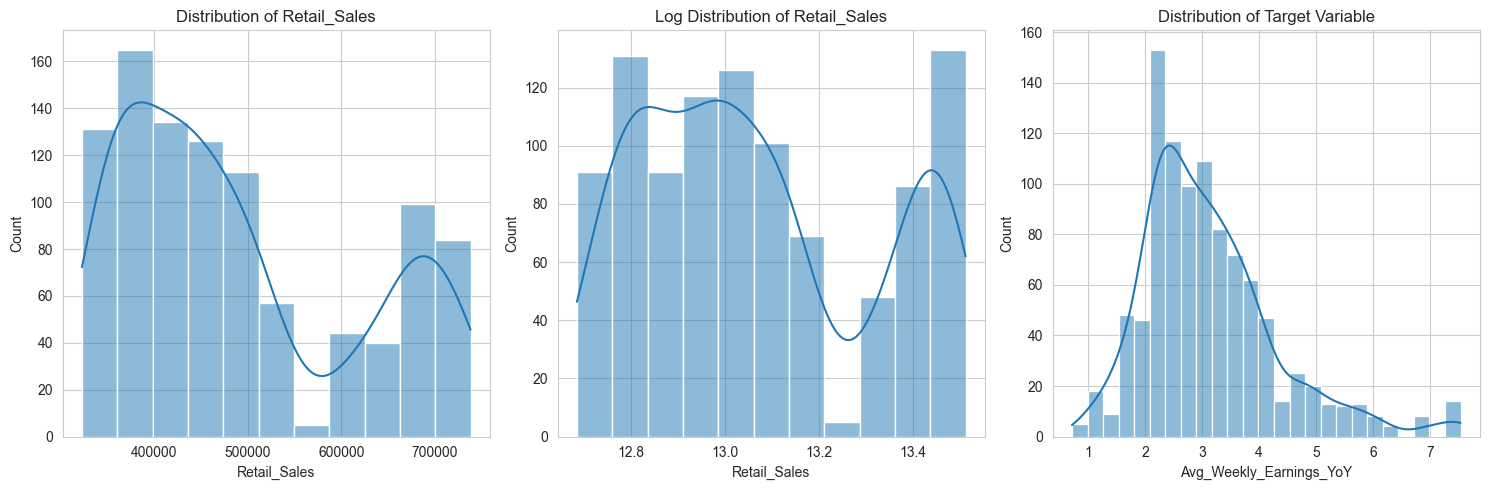

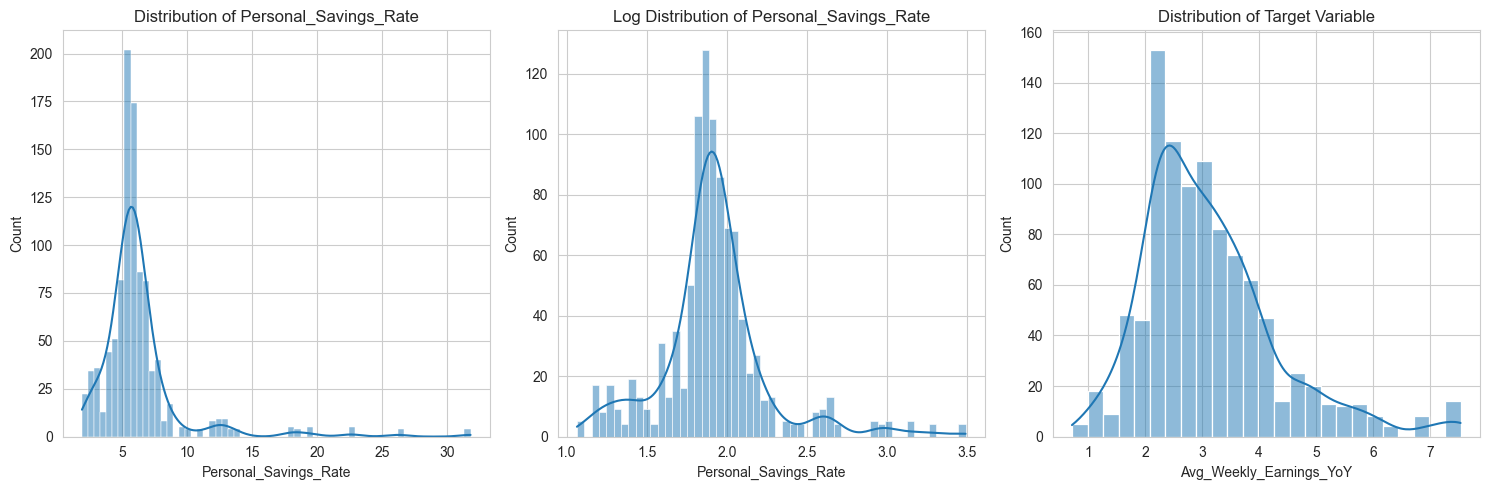

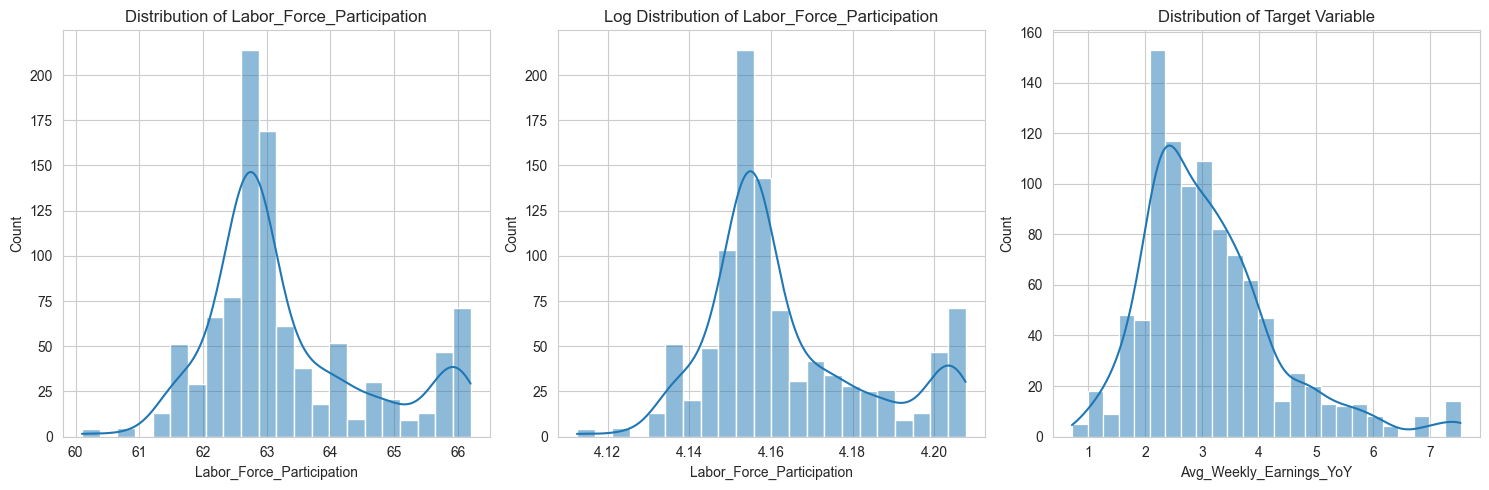

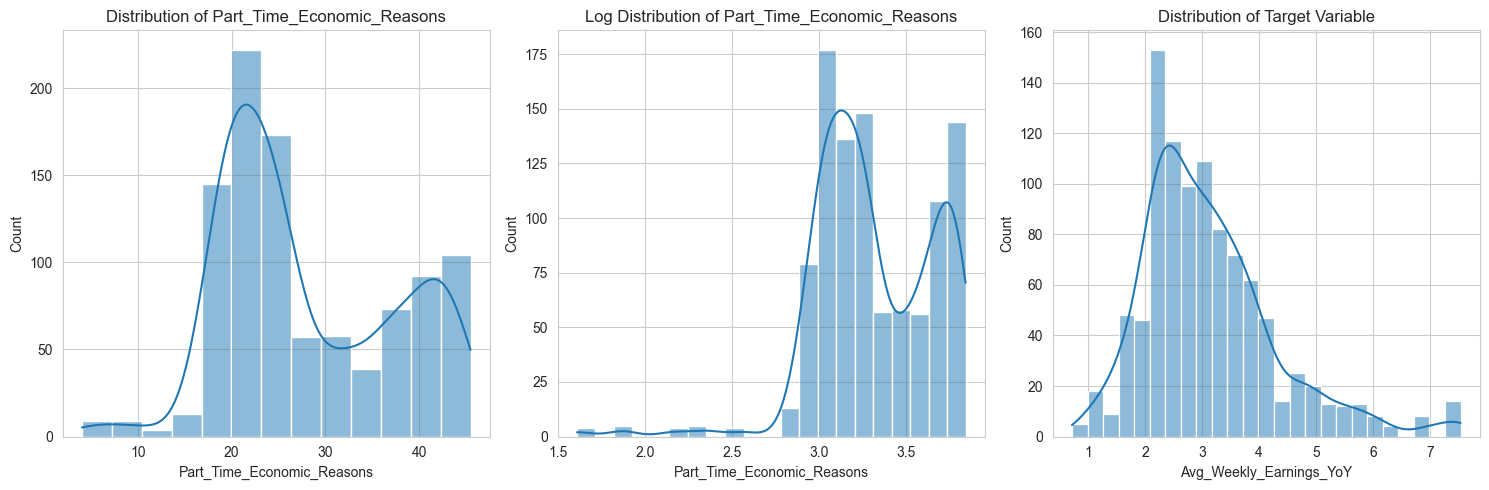

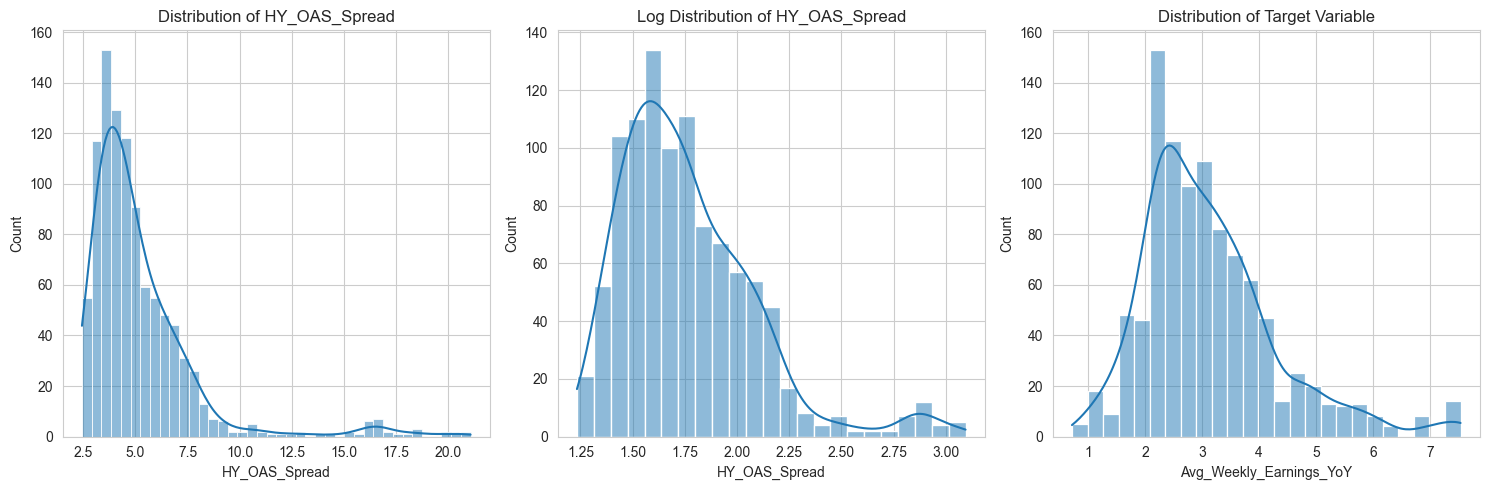

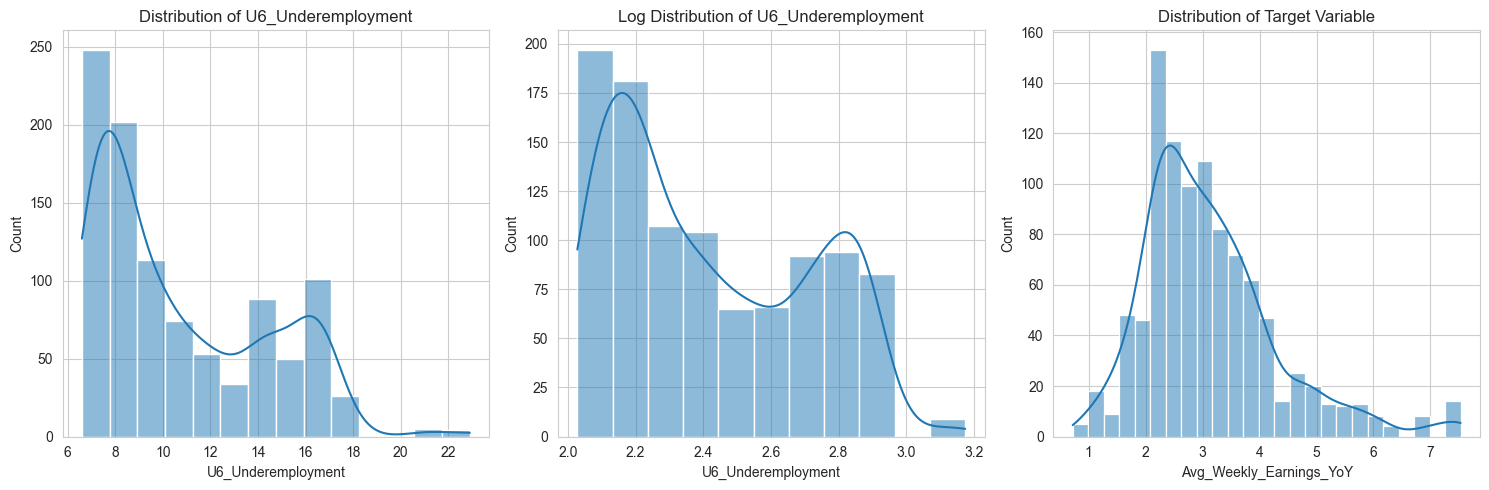

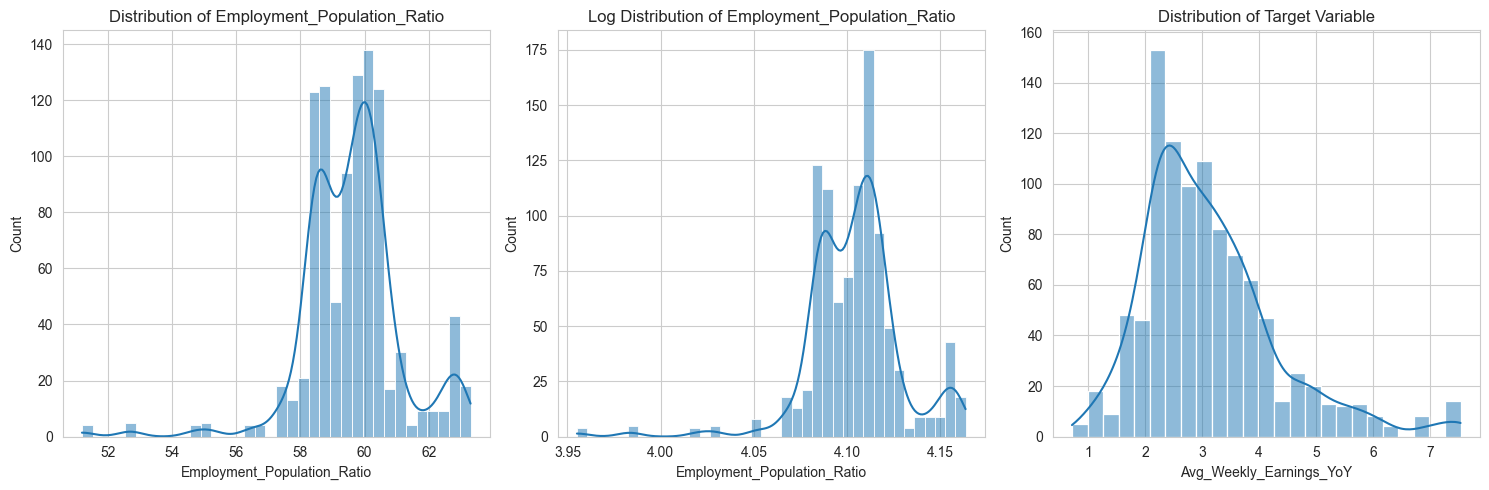

In [10]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================
from matplotlib import axes


most_important_features: list[str] = [
    "Avg_Weekly_Earnings_YoY",      # target variable
    "Unemployment_Rate",        # single strongest inverse predictor of wage growth
    "JOLTS_UE_Ratio",           # labor market tightness → bargaining power
    "CPI_YoY",                  # nominal earnings track price level
    "Core_PCE_YoY",             # Fed's preferred inflation gauge
    "Employment_Population_Ratio",  # broad labor utilization
    "Nonfarm_Payrolls",         # employment level / demand for labor
    "Industrial_Production",    # real output → derived demand for workers
    "Real_FFR_PCE",             # real monetary stance → hiring/investment
    "Activity_Momentum",        # composite demand signal
    "Sahm_Indicator",           # recession proximity
    "JOLTS_Quits",          # worker confidence in labor market
    "Retail_Sales",         # consumer demand → business revenue and wage growth
    "Personal_Savings_Rate",    # consumer financial health → spending and wage pressure
    "Labor_Force_Participation",   # labor supply → wage pressure
    "Part_Time_Economic_Reasons",    # underemployment → slack in labor market
    "HY_OAS_Spread",    # credit market stress → economic conditions
    "U6_Underemployment",    # broadest measure of labor market slack
    "Employment_Population_Ratio",    # broad labor market utilization
]  

def plot_feature_distributions(df, feature, target='Avg_Weekly_Earnings_YoY'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {feature}')
    log_feature = np.log1p(df[feature])  # log-transform to handle skewness
    sns.histplot(log_feature, kde=True, ax=axes[1])
    axes[1].set_title(f'Log Distribution of {feature}')

    sns.histplot(df[target], kde=True, ax=axes[2])
    axes[2].set_title('Distribution of Target Variable')

    plt.tight_layout()
    plt.show()

for feature in most_important_features:
    plot_feature_distributions(df, feature)


### 2.5 Outlier Detection

In [11]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================
all_cols = [col for col in df.columns if col not in ('date')]
def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR


for col in all_cols:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

Unemployment_Rate: 9 outliers (0.9%)
U6_Underemployment: 0 outliers (0.0%)
Nonfarm_Payrolls: 0 outliers (0.0%)
JOLTS_Quits: 0 outliers (0.0%)
Employment_Population_Ratio: 53 outliers (5.3%)
Part_Time_Economic_Reasons: 0 outliers (0.0%)
Labor_Force_Participation: 13 outliers (1.3%)
Initial_Jobless_Claims: 65 outliers (6.5%)
JOLTS_UE_Ratio: 0 outliers (0.0%)
Sahm_Indicator: 139 outliers (13.9%)
Payroll_Change_4w: 100 outliers (10.0%)
Industrial_Production: 95 outliers (9.5%)
Capacity_Utilization: 82 outliers (8.2%)
Retail_Sales: 0 outliers (0.0%)
Leading_Index_CB: 153 outliers (15.3%)
Activity_Momentum: 108 outliers (10.8%)
CPI_YoY: 91 outliers (9.1%)
Core_PCE_YoY: 81 outliers (8.1%)
Inflation_Momentum: 70 outliers (7.0%)
Real_FFR_PCE: 61 outliers (6.1%)
Taylor_Gap: 52 outliers (5.2%)
Treasury_10Y: 0 outliers (0.0%)
HY_OAS_Spread: 45 outliers (4.5%)
Chicago_Fed_Financial_Conditions: 103 outliers (10.3%)
Flag_Curve_Inverted_10Y2Y: 122 outliers (12.2%)
Personal_Savings_Rate: 121 outliers (

**Outlier strategy:** Keep 


This outliers occur likely during times of economic shock, (2008, COVID) and thus do not represent unreleastic or unrepresentative data. Another intuition that backs up this strategy is that outliers will likely move with one another, in that if one feature experiences a period of outlier behavior, odds are that other columns are also exhibiting such behavior. This is due to the naeture of economic response and time-series data.

In [12]:
# create COVID dummy flag 

df["Covid_Flag"] = df["date"].str.contains("2020|2021").astype(int)

### 2.6 Correlations

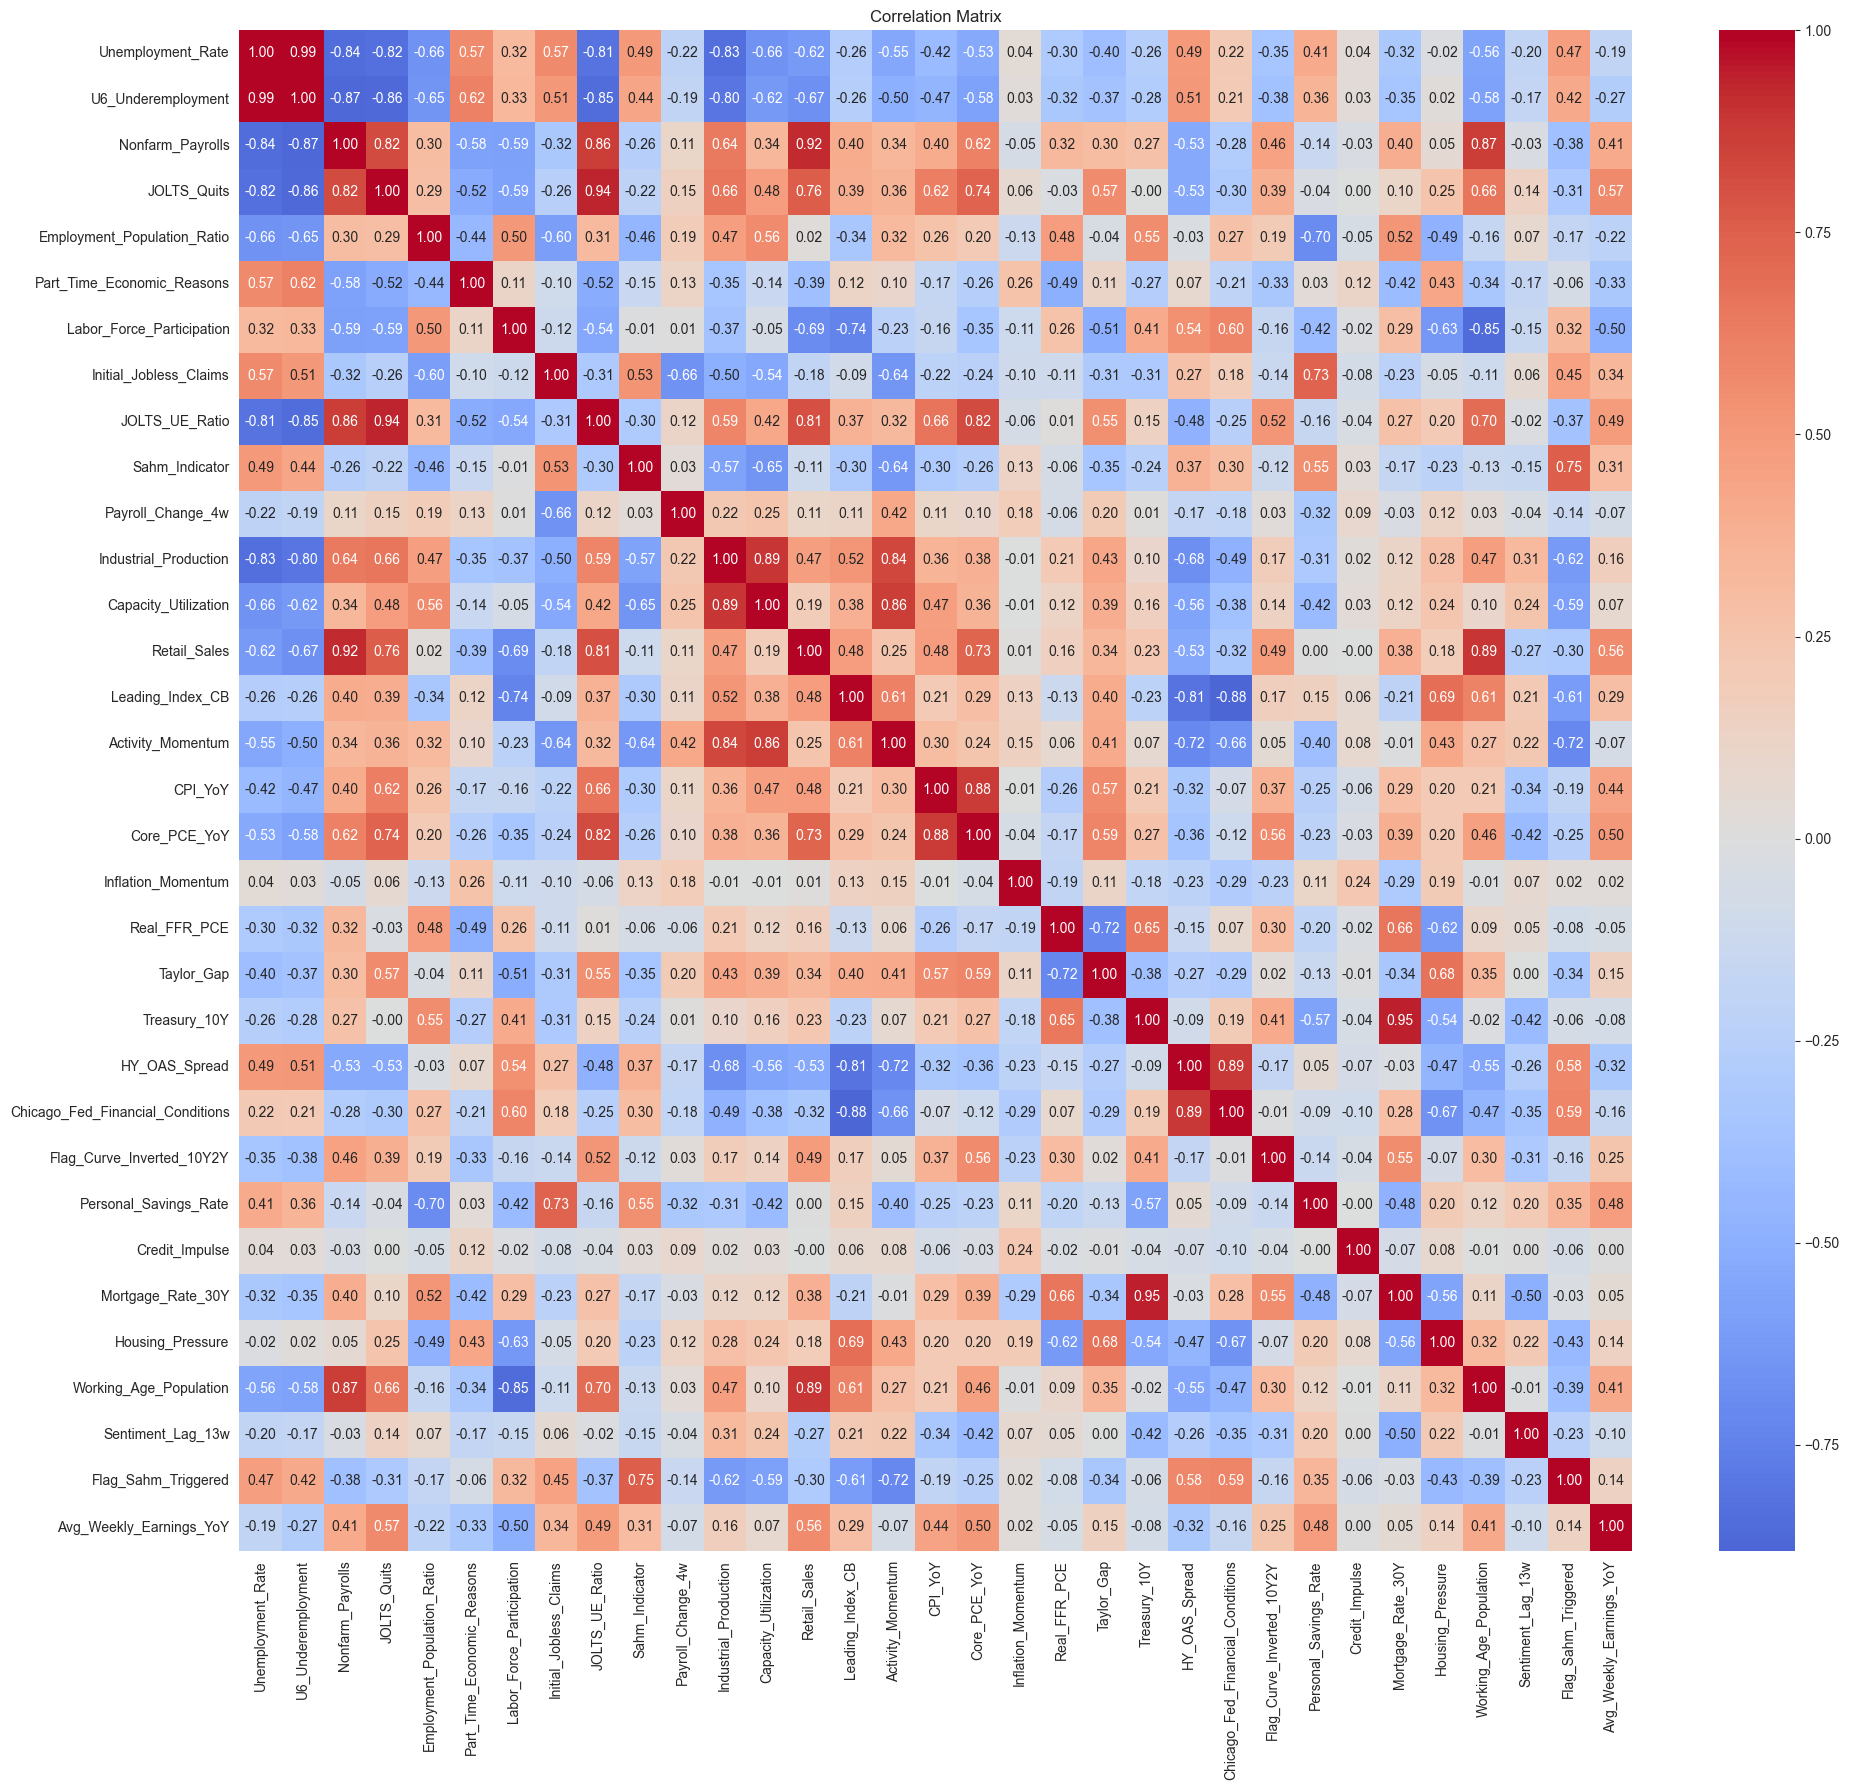

In [13]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ('year', 'Covid_Flag')]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
# get most highly correlated features with the target variable (positive or negative)

target_correlation = corr_matrix['Avg_Weekly_Earnings_YoY'].drop('Avg_Weekly_Earnings_YoY')
most_postive_corr = target_correlation.sort_values(ascending=False).head(5)
most_negative_corr = target_correlation.sort_values().head(5)
print('Top 5 most positively correlated features with target:')
print(most_postive_corr)
print('\nTop 5 most negatively correlated features with target:')
print(most_negative_corr)


Top 5 most positively correlated features with target:
JOLTS_Quits              0.569745
Retail_Sales             0.563689
Core_PCE_YoY             0.502109
JOLTS_UE_Ratio           0.490030
Personal_Savings_Rate    0.479776
Name: Avg_Weekly_Earnings_YoY, dtype: float64

Top 5 most negatively correlated features with target:
Labor_Force_Participation     -0.503299
Part_Time_Economic_Reasons    -0.329841
HY_OAS_Spread                 -0.318806
U6_Underemployment            -0.271417
Employment_Population_Ratio   -0.221899
Name: Avg_Weekly_Earnings_YoY, dtype: float64


### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

  My target variable is normally distributed, it does not require trimming or transformation. 

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   Top 5 most positively correlated features with target:
-   JOLTS_Quits              0.569745
-   Retail_Sales             0.563689
-   Core_PCE_YoY             0.502109
-   JOLTS_UE_Ratio           0.490030
-   Personal_Savings_Rate    0.479776
   

   Top 5 most negatively correlated features with target:
-   Labor_Force_Participation     -0.503299
-   Part_Time_Economic_Reasons    -0.329841
-   HY_OAS_Spread                 -0.318806
-   U6_Underemployment            -0.271417
-   Employment_Population_Ratio   -0.221899

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   Covid era measurements likely represent most of the outliers, I will include a dummy variable during the COVID years such that my model can interpret these results as unique time periods.

In [15]:
# ── Swap non-stationary levels for stationary alternatives ────────────
STATIONARY_SWAPS: dict[str, str] = {
    "Retail_Sales":              "Activity_Momentum",       # composite z-score includes retail
    "JOLTS_Quits":               "Payroll_Change_4w",       # labor momentum, already differenced
    "Part_Time_Economic_Reasons": "Sahm_Indicator",         # labor slack, already a spread
}

most_important_features = list(most_postive_corr.index) + list(most_negative_corr.index)
most_important_features = [
    STATIONARY_SWAPS.get(f, f) for f in most_important_features
]

print("Most important features based on correlation with target:")
print(most_important_features)

Most important features based on correlation with target:
['Payroll_Change_4w', 'Activity_Momentum', 'Core_PCE_YoY', 'JOLTS_UE_Ratio', 'Personal_Savings_Rate', 'Labor_Force_Participation', 'Sahm_Indicator', 'HY_OAS_Spread', 'U6_Underemployment', 'Employment_Population_Ratio']


### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 998** observations and **M = 36** features.

**Missing data:** 0% of cells are missing.

**Outliers:** I identified minimal outliers using [Tukey Fences / IQR / visual inspection]. I will handle them by keeping them since they will be accompanied by the COVID flag.

**Target variable:** Avg_Weekly_Earnings_YoY exhibits a normal distribution with a slight rightward skew. 

**Key finding from EDA:** The highly correlated columns, COVID era outliers, distribution of key variables that may need transformation.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [16]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================
def train_test_split_temporal(df, features, target):
    X = df[features]
    y = df[target]

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    split_date = df['date'].iloc[split_idx]
    print(f'Train: {X_train.shape[0]} samples (up to {split_date})')
    print(f'Test:  {X_test.shape[0]} samples (after {split_date})')

    return X_train, X_test, y_train, y_test

def train_test_split_random(df, features, target):
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    print(f'Train: {X_train.shape[0]} samples')
    print(f'Test:  {X_test.shape[0]} samples')

    return X_train, X_test, y_train, y_test


# compare both splitting methods 
print("Temporal Train/Test Split:")
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split_temporal(df, most_important_features, 'Avg_Weekly_Earnings_YoY')
print("\n" + "="*50 + "\n")
# random split is not appropriate for time series data, but we will run it for comparison purposes
# show date range 
print(f"Full dataset date range: {df['date'].min()} to {df['date'].max()}")
print(f"Temporal split date: {df['date'].iloc[int(len(df)*0.8)]}")
# number features in each split
print(f"Temporal split - Train features: {X_train_temp.shape[1]}, Test features: {X_test_temp.shape[1]}")
print("\nRandom Train/Test Split:")
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split_random(df, most_important_features, 'Avg_Weekly_Earnings_YoY')
print("\n" + "="*50 + "\n")
# show date range
print(f"Full dataset date range: {df['date'].min()} to {df['date'].max()}")
print(f"Random split date: {df['date'].iloc[int(len(df)*0.8)]}")
# number features in each split
print(f"Random split - Train features: {X_train_rand.shape[1]}, Test features: {X_test_rand.shape[1]}")


# assing global temporary variables for use in modeling section
X_train, X_test, y_train, y_test = train_test_split_temporal(df, most_important_features, 'Avg_Weekly_Earnings_YoY')

Temporal Train/Test Split:
Train: 798 samples (up to 2022-06-17)
Test:  200 samples (after 2022-06-17)


Full dataset date range: 2007-03-02 to 2026-04-10
Temporal split date: 2022-06-17
Temporal split - Train features: 10, Test features: 10

Random Train/Test Split:
Train: 798 samples
Test:  200 samples


Full dataset date range: 2007-03-02 to 2026-04-10
Random split date: 2022-06-17
Random split - Train features: 10, Test features: 10
Train: 798 samples (up to 2022-06-17)
Test:  200 samples (after 2022-06-17)


### 3.2 Model 1: Baseline

In [17]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================

def build_model1():
    from sklearn.linear_model import LinearRegression
    model_1 = LinearRegression()
    return model_1

model_1 = build_model1()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

def build_model2():
    from sklearn.linear_model import Ridge
    model_2 = Ridge(alpha=1.0, max_iter=1000, random_state=RANDOM_STATE)
    return model_2

model_2 = build_model2()
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

# ========

print(f'Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'Linear Regression MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'Linear Regression R2:   {r2_score(y_test, y_pred_1):.4f}')

print(f'Ridge RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'Ridge MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'Ridge R2:   {r2_score(y_test, y_pred_2):.4f}')

Linear Regression RMSE: 0.4795
Linear Regression MAE:  0.3673
Linear Regression R2:   -0.3388
Ridge RMSE: 0.4847
Ridge MAE:  0.3733
Ridge R2:   -0.3679


### 3.3 Model 2: Your Choice

In [18]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================

def build_model3():
    from sklearn.ensemble import GradientBoostingRegressor
    model_3 = GradientBoostingRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )
    return model_3

model_3 = build_model3()
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)
print(f'Gradient Boosting RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_3)):.4f}')
print(f'Gradient Boosting MAE:  {mean_absolute_error(y_test, y_pred_3):.4f}')
print(f'Gradient Boosting R2:   {r2_score(y_test, y_pred_3):.4f}')


Gradient Boosting RMSE: 0.5877
Gradient Boosting MAE:  0.4872
Gradient Boosting R2:   -1.0115


#### Find Whether Lagged Indicators improve model significantly

In [19]:
from typing import Callable

def get_time_series_split_object():
    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    return tscv

def full_analysis(most_important_features: list[str], tts: Callable):
    from sklearn.linear_model import LinearRegression, Ridge
    X = df[most_important_features]
    y = df["Avg_Weekly_Earnings_YoY"]
    tscv = get_time_series_split_object()

    X_train, X_test, y_train, y_test = tts(
        df, most_important_features, "Avg_Weekly_Earnings_YoY"
    )

    # ── Define models ─────────────────────────────────────────────────
    models = {
        "Linear Regression": build_model1(),
        "Ridge (α=1.0)":build_model2(),
        "Gradient Boosting": build_model3(),
    }

    # ── Run all models ────────────────────────────────────────────────
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X, y, cv=tscv, scoring="r2")

        results[name] = {
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "mae": mean_absolute_error(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "cv_r2_mean": cv_scores.mean(),
            "cv_r2_std": cv_scores.std(),
            "model": model,
            "y_pred": y_pred,
        }

    # ── Print results ─────────────────────────────────────────────────
    header = f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'CV R² (5-fold)':>18}"
    print("\n" + "=" * len(header))
    print(header)
    print("=" * len(header))

    for name, r in results.items():
        cv_str = f"{r['cv_r2_mean']:>6.4f} ± {r['cv_r2_std']:.4f}"
        print(
            f"{name:<22} {r['rmse']:>8.4f} {r['mae']:>8.4f} {r['r2']:>8.4f} {cv_str:>18}"
        )

    print("=" * len(header))

    # ── Best model summary ────────────────────────────────────────────
    best_name = max(results, key=lambda k: results[k]["cv_r2_mean"])
    best = results[best_name]
    print(f"\n→ Best by CV R²: {best_name} ({best['cv_r2_mean']:.4f} ± {best['cv_r2_std']:.4f})")

    return results
most_important1 = most_important_features
df['Earnings_YoY_Lag4'] = df['Avg_Weekly_Earnings_YoY'].shift(4)
df['Earnings_YoY_Lag13'] = df['Avg_Weekly_Earnings_YoY'].shift(13)
df = df.dropna()

most_important2 = most_important_features + [
    'Earnings_YoY_Lag4',
    'Earnings_YoY_Lag13',
]

for tts_func in [train_test_split_temporal, train_test_split_random]:
    for features in (most_important1, most_important2):
        print(f"\n{'='*40}\nTesting with {tts_func.__name__}\n{'='*40}")
        full_analysis(features, tts_func)


Testing with train_test_split_temporal
Train: 788 samples (up to 2022-07-08)
Test:  197 samples (after 2022-07-08)

Model                      RMSE      MAE       R²     CV R² (5-fold)
Linear Regression        0.4764   0.3634  -0.4187   -3.0052 ± 3.7345
Ridge (α=1.0)            0.4827   0.3697  -0.4561   -2.9445 ± 3.2481
Gradient Boosting        0.7698   0.6510  -2.7038   -2.3748 ± 1.4050

→ Best by CV R²: Gradient Boosting (-2.3748 ± 1.4050)

Testing with train_test_split_temporal
Train: 788 samples (up to 2022-07-08)
Test:  197 samples (after 2022-07-08)

Model                      RMSE      MAE       R²     CV R² (5-fold)
Linear Regression        0.3977   0.3169   0.0112   -1.0650 ± 1.1918
Ridge (α=1.0)            0.3965   0.3162   0.0171   -1.0201 ± 1.0206
Gradient Boosting        0.4525   0.3763  -0.2799   -0.6873 ± 0.9768

→ Best by CV R²: Gradient Boosting (-0.6873 ± 0.9768)

Testing with train_test_split_random
Train: 788 samples
Test:  197 samples

Model                      

In [20]:
# final model object wrappers with optimal feature set and train/test split method
global most_important_final
most_important_final = most_important2

global X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split_temporal(df, most_important_final, 'Avg_Weekly_Earnings_YoY')

def model1():
    model1 = build_model1()
    model1.fit(X_train, y_train)
    return model1

def model2():
    model2 = build_model2()
    model2.fit(X_train, y_train)
    return model2

def model3():
    model3 = build_model3()
    model3.fit(X_train, y_train)
    return model3

Train: 788 samples (up to 2022-07-08)
Test:  197 samples (after 2022-07-08)


### 3.4 Cross-Validation Comparison

In [21]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scoring = ['r2', 'neg_mean_squared_error']

for score in scoring:
    model_1 = build_model1()
    model_2 = build_model2()
    model_3 = build_model3()
    cv_1 = cross_val_score(model_1, X_train, y_train, cv=tscv, scoring=score)
    cv_2 = cross_val_score(model_2, X_train, y_train, cv=tscv, scoring=score)
    cv_3 = cross_val_score(model_3, X_train, y_train, cv=tscv, scoring=score)

    print(f'Model 1 CV {score}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
    print(f'Model 2 CV {score}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
    print(f'Model 3 CV {score}: {cv_3.mean():.4f} +/- {cv_3.std():.4f}')


Model 1 CV r2: -2.5609 +/- 2.5138
Model 2 CV r2: -1.6006 +/- 1.2514
Model 3 CV r2: -1.4195 +/- 0.6489
Model 1 CV neg_mean_squared_error: -2.2042 +/- 3.8160
Model 2 CV neg_mean_squared_error: -1.9920 +/- 3.5513
Model 3 CV neg_mean_squared_error: -1.6819 +/- 2.8673


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

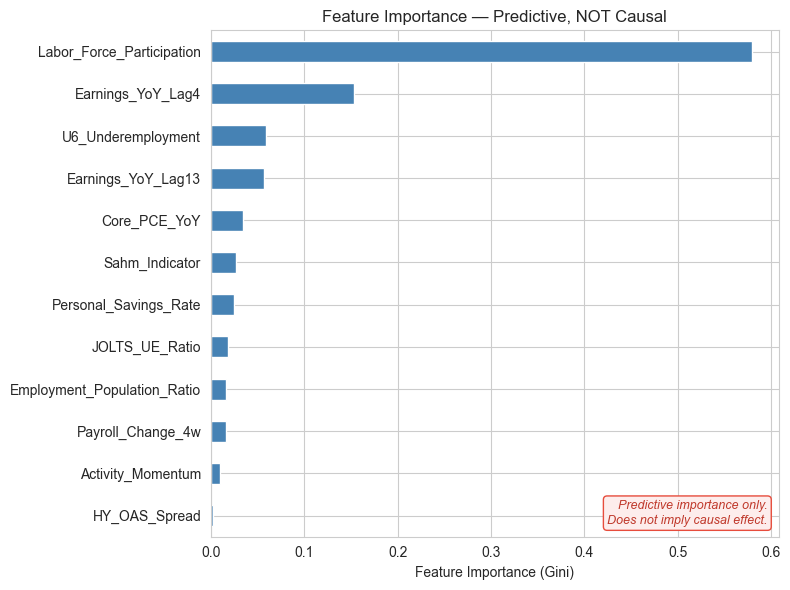

In [22]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================
_model3 = model3()
# For tree-based models:
importances = pd.Series(
    _model3.feature_importances_, index=most_important_final
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

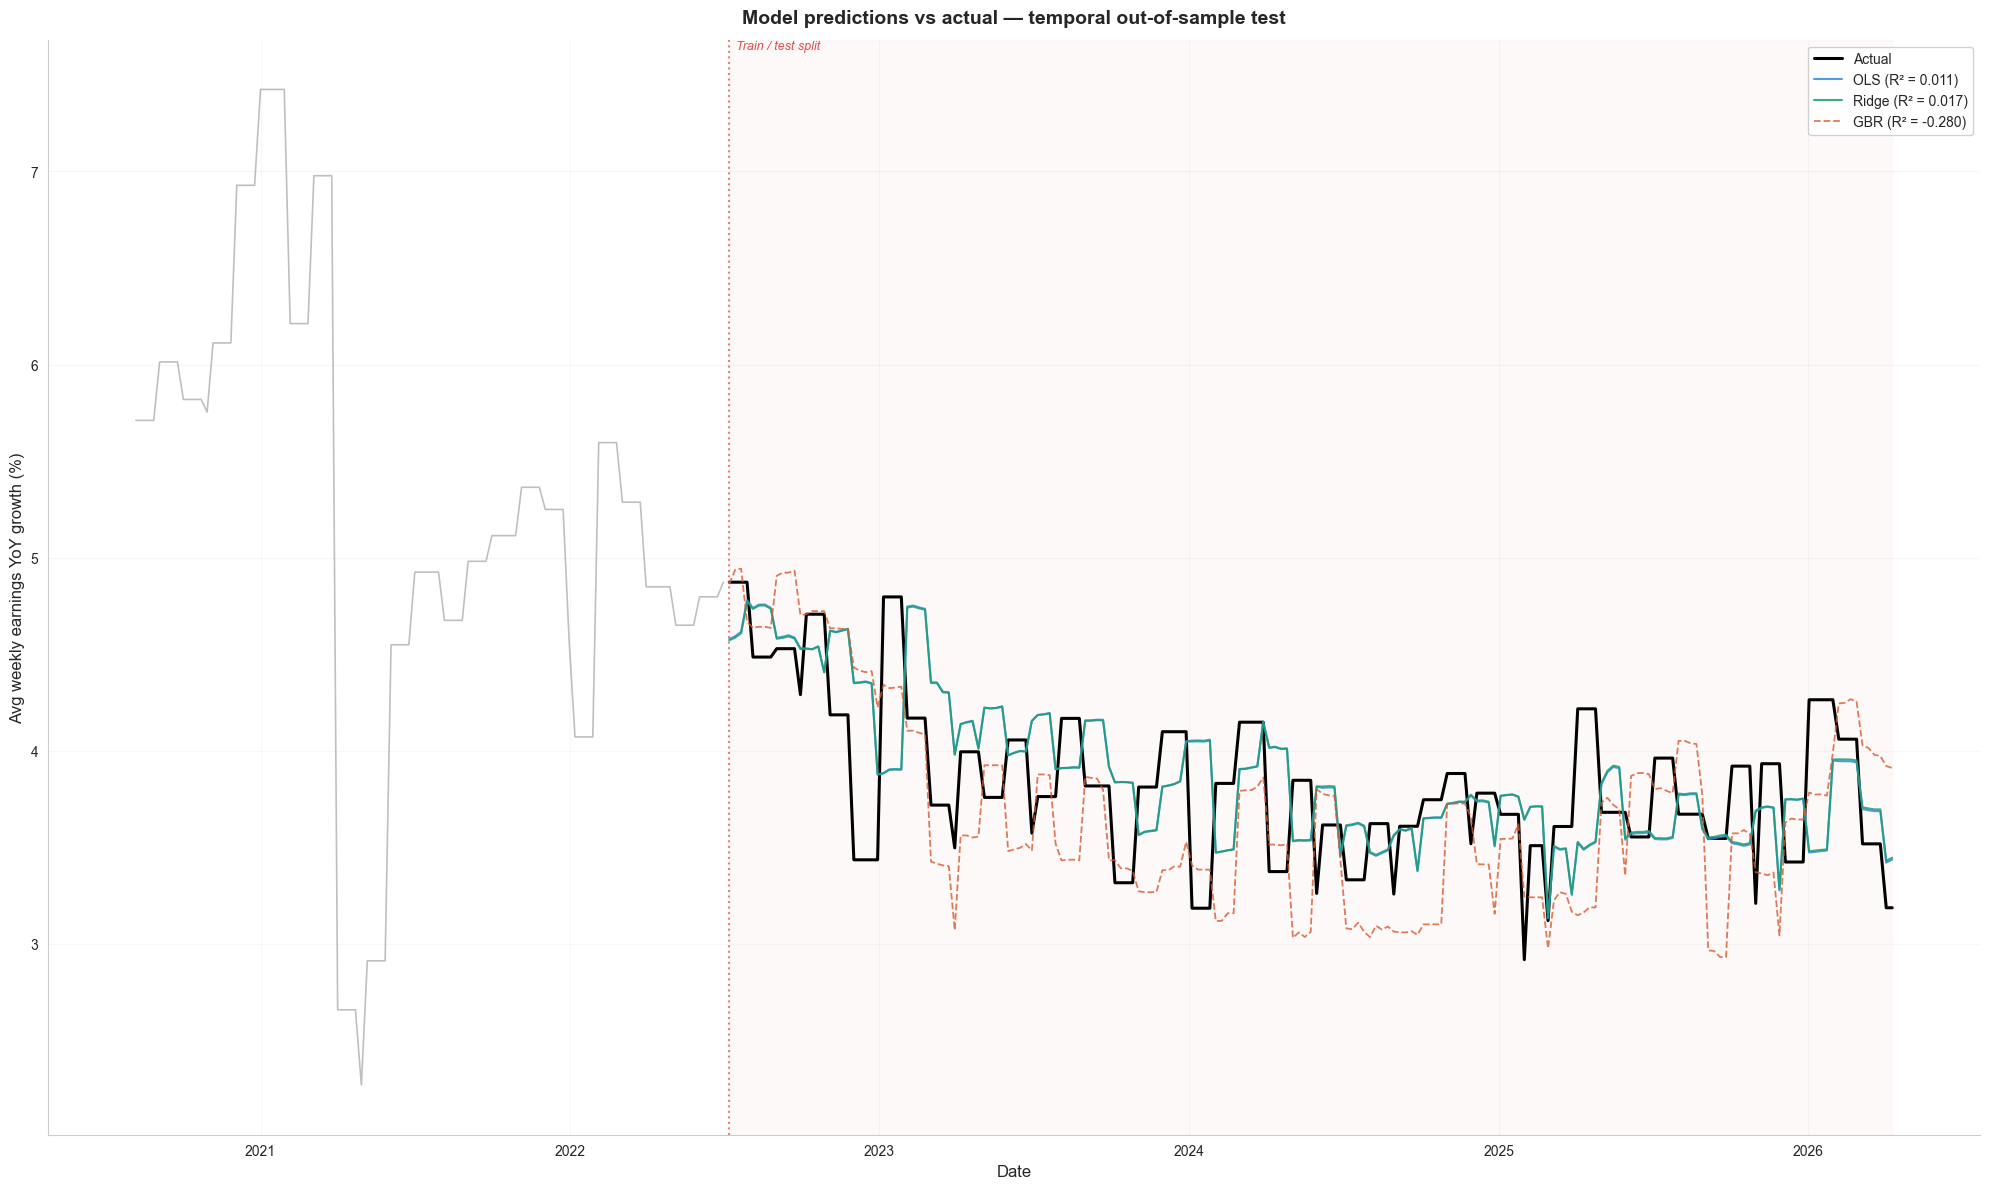

In [23]:
m1 = build_model1().fit(X_train, y_train)
m2 = build_model2().fit(X_train, y_train)
m3 = build_model3().fit(X_train, y_train)

pred_1 = m1.predict(X_test)
pred_2 = m2.predict(X_test)
pred_3 = m3.predict(X_test)
ctx = 100
test_dates = pd.to_datetime(df['date'].loc[X_test.index])
split_date = test_dates.iloc[0]
train_tail_dates = pd.to_datetime(df['date'].loc[X_train.index[-ctx:]])
train_tail_y = y_train.iloc[-ctx:]

fig, ax = plt.subplots(figsize=(20, 12))

# training context (dimmed)
ax.plot(train_tail_dates, train_tail_y, color='black', alpha=0.25, linewidth=1.2)

# actual test
ax.plot(test_dates, y_test.values, color='black', linewidth=2.2, label='Actual')

# model predictions
ax.plot(test_dates, pred_1, color='#378ADD', linewidth=1.5, alpha=0.85,
        label=f'OLS (R² = {r2_score(y_test, pred_1):.3f})')
ax.plot(test_dates, pred_2, color='#1D9E75', linewidth=1.5, alpha=0.85,
        label=f'Ridge (R² = {r2_score(y_test, pred_2):.3f})')
ax.plot(test_dates, pred_3, color='#D85A30', linewidth=1.3, alpha=0.8, linestyle='--',
        label=f'GBR (R² = {r2_score(y_test, pred_3):.3f})')

# split line
ax.axvline(split_date, color='#E24B4A', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(split_date, ax.get_ylim()[1], '  Train / test split',
        color='#E24B4A', fontsize=9, va='top', ha='left', style='italic')

# shading on test region
ax.axvspan(split_date, test_dates.iloc[-1], alpha=0.03, color='#E24B4A')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Avg weekly earnings YoY growth (%)', fontsize=12)
ax.set_title('Model predictions vs actual — temporal out-of-sample test',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
most_important_final

['Payroll_Change_4w',
 'Activity_Momentum',
 'Core_PCE_YoY',
 'JOLTS_UE_Ratio',
 'Personal_Savings_Rate',
 'Labor_Force_Participation',
 'Sahm_Indicator',
 'HY_OAS_Spread',
 'U6_Underemployment',
 'Employment_Population_Ratio',
 'Earnings_YoY_Lag4',
 'Earnings_YoY_Lag13']

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

- Situation: 

Labor economists and policymakers at institutions such as the Bureau of Labor Statistics and the Federal Reserve rely on macroeconomic indicators to anticipate wage trends when setting monetary policy and evaluating labor market health. The key question is whether observable macro conditions, including labor market tightness, inflation, financial conditions, and output measures, can reliably forecast the trajectory of average weekly earnings growth. We constructed a dataset of 32 features drawn from FRED economic series and derived scoring indicators, sampled weekly from 2007 through 2026, with year-over-year wage growth (Avg_Weekly_Earnings_YoY) as the prediction target.

- Complication: 

Despite strong contemporaneous correlations between macro features and wage growth, none of the three models tested (OLS linear regression, Ridge regression, and Gradient Boosting) produced positive R² on temporally honest evaluation. On the held-out post-July 2022 test set, the best performer was Ridge at R² = -0.058, meaning it predicted slightly worse than simply guessing the training-period mean. Gradient Boosting, despite being the most flexible model, performed worst (R² = -1.067), as its tree-based architecture memorized training-era relationships that inverted during the post-pandemic wage deceleration. Adding autoregressive lag features (4-week and 13-week) improved RMSE from 0.48 to 0.40 but still could not push R² above zero. The fundamental issue is regime dependence: the macro-to-earnings relationship shifts across economic cycles. What drives wages in a tight labor market (2018 to 2022) does not hold during normalization (2022 to 2026), and the model has no way to know which regime it is in.

- Resolution: 

We recommend against using macro-indicator models alone for short-horizon wage growth forecasting. The most defensible approach is a simple autoregressive baseline, predicting that next quarter's wage growth will resemble this quarter's, augmented by a narrow set of labor market indicators. Feature importance analysis identified U6 underemployment and the JOLTS job-openings-to-unemployed ratio as the only macro features that contributed meaningful predictive signal beyond the lags. For policy applications, these models are better suited as diagnostic tools (understanding what correlates with wage movements after the fact) than as prognostic tools (forecasting where wages are heading).

- Uncertainty statement: 

Based on our temporal cross-validation results (CV R² = -1.51 ± 1.21 for the best model, Gradient Boosting), we estimate that macro-based wage growth forecasts will underperform a naive mean baseline in the majority of forward-looking evaluation windows. The primary limitation is non-stationarity in the feature-target relationship across macro regimes, compounded by the compositional distortions in the BLS earnings series during the COVID period (2020 to 2021). We recommend interpreting these models as descriptive rather than predictive, with the caveat that any deployment in a forecasting context should incorporate regime-detection mechanisms and be benchmarked against a simple random-walk baseline before adoption.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

Permanent URL:

[https://average-weekly-earnings-prediction-model-iasolb.streamlit.app/](https://average-weekly-earnings-prediction-model-iasolb.streamlit.app/)

In [25]:
# dump all final models 

import joblib
joblib.dump(model1(), 'data/models/ols.pkl');
joblib.dump(model2(), 'data/models/ridge.pkl');
joblib.dump(model3(), 'data/models/gbr.pkl');

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___